In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [7]:
data = sns.load_dataset('penguins')
data = data.dropna()
train, test = train_test_split(
    data, test_size = 0.4,
    stratify = data['species'],
    random_state = 36
)

In [8]:
rn = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cn = ['gentoo', 'adelie', 'chinstrap']

x_train = train[rn]
y_train = train['species']

x_test = test[rn]
y_test = test['species']

In [9]:
gnb_model = GaussianNB()
gnb_model.fit(x_train, y_train)
prediction = gnb_model.predict(x_test)

In [11]:
efficiency = metrics.accuracy_score(prediction, y_test)
efficiency

0.9701492537313433

In [12]:
test['y_pred'] = prediction
test

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,y_pred
225,Gentoo,Biscoe,46.5,13.5,210.0,4550.0,Female,Gentoo
88,Adelie,Dream,38.3,19.2,189.0,3950.0,Male,Adelie
176,Chinstrap,Dream,46.7,17.9,195.0,3300.0,Female,Chinstrap
296,Gentoo,Biscoe,47.5,14.2,209.0,4600.0,Female,Gentoo
298,Gentoo,Biscoe,45.2,13.8,215.0,4750.0,Female,Gentoo
...,...,...,...,...,...,...,...,...
26,Adelie,Biscoe,40.6,18.6,183.0,3550.0,Male,Adelie
320,Gentoo,Biscoe,48.5,15.0,219.0,4850.0,Female,Gentoo
180,Chinstrap,Dream,46.4,17.8,191.0,3700.0,Female,Chinstrap
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male,Adelie


In [14]:
print(metrics.classification_report(y_test, prediction))

              precision    recall  f1-score   support

      Adelie       1.00      0.93      0.96        59
   Chinstrap       0.87      1.00      0.93        27
      Gentoo       1.00      1.00      1.00        48

    accuracy                           0.97       134
   macro avg       0.96      0.98      0.97       134
weighted avg       0.97      0.97      0.97       134



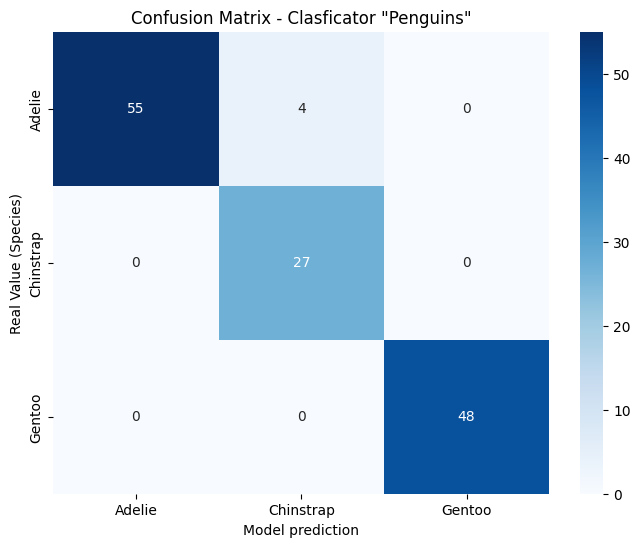

In [18]:
cm = metrics.confusion_matrix(y_test, prediction)
fig = plt.figure(figsize=(8,6))

sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels = gnb_model.classes_,
    yticklabels = gnb_model.classes_
)
plt.xlabel('Model prediction')
plt.ylabel('Real Value (Species)')
plt.title('Confusion Matrix - Clasficator "Penguins"')
plt.show()